<a href="https://colab.research.google.com/github/neetagt/Data-Analysis-with-Python/blob/main/SeaLevelPredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

def draw_plot():
    # Read data from file
    df = pd.read_csv("epa-sea-level.csv")  # FIXED path

    # Create scatter plot using all data
    fig, ax = plt.subplots()
    ax.scatter(df["Year"], df["CSIRO Adjusted Sea Level"], label="Original Data")

    # First line of best fit (use all data)
    res1 = linregress(df["Year"], df["CSIRO Adjusted Sea Level"])
    x1 = np.arange(df["Year"].min(), 2051)
    y1 = res1.intercept + res1.slope * x1
    ax.plot(x1, y1, 'r', label="Best Fit: All Data")

    # Second line of best fit (from year 2000)
    df_recent = df[df["Year"] >= 2000]
    res2 = linregress(df_recent["Year"], df_recent["CSIRO Adjusted Sea Level"])
    x2 = np.arange(2000, 2051)
    y2 = res2.intercept + res2.slope * x2
    ax.plot(x2, y2, 'g', label="Best Fit: From 2000")

    # Labels and title
    ax.set_xlabel("Year")
    ax.set_ylabel("Sea Level (inches)")
    ax.set_title("Rise in Sea Level")

    # Set x-tick labels to match test expectations
    ax.set_xticks([1850.0, 1875.0, 1900.0, 1925.0, 1950.0, 1975.0, 2000.0, 2025.0, 2050.0, 2075.0])

    # Add legend
    ax.legend()

    # Save and return
    plt.savefig("sea_level_plot.png")
    return plt.gca()


<Axes: title={'center': 'Rise in Sea Level'}, xlabel='Year', ylabel='Sea Level (inches)'>

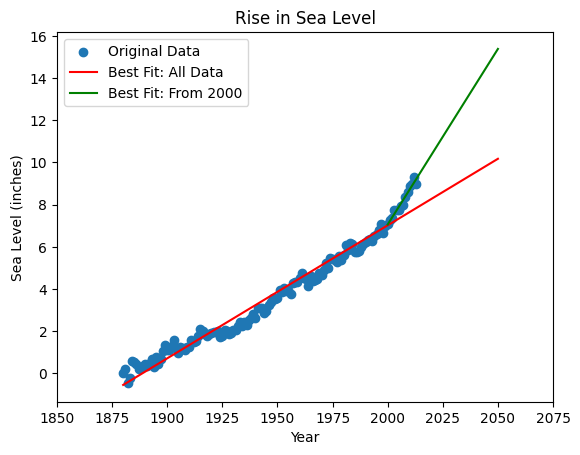

In [6]:
draw_plot()